In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1

def single_S(y,x_left,x_right,y_below,y_upper,center,r): # Single source
    cond=(y[:,0]-center[0])**2+(y[:,1]-center[1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))*cond

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): # Total source
    cond1=(y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2<=r**2
    cond2=(y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2))*cond1+0.5*np.exp(-550*((y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2))*cond2



cuda:1


In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
b_x_min,b_x_max,b_y_min,b_y_max=-0.35,0.35,-0.35,0.35 # On boundary Gamma

num_batches_gauss=1
b_n=20
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[-0.06,0.0],[0.08,0.0]])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_circle(kk, number_gene, points_b, single_S,[],[],[],[],center_true[0],r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene, points_b, single_S, [],[],[],[],center_true[1], r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b0 = F_mea_b1 + F_mea_b2
F_mea_db_x10 = F_mea_db_x11 + F_mea_db_x12
F_mea_db_x20= F_mea_db_x21 + F_mea_db_x22
F=inverse_solver.F(F_mea_b0,F_mea_db_x10,F_mea_db_x20)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


/data1/hxw-b25/MA-RFM/Ex4.4/../main_code/2d/generate_data.py:474: PerformanceWarning: The device where the array resides (0) is different from the current device (1). Peer access has been activated automatically.
  w_sol_y1=self._geom_factor()*result_y1*self.w
/data1/hxw-b25/MA-RFM/Ex4.4/../main_code/2d/generate_data.py:498: PerformanceWarning: The device where the array resides (0) is different from the current device (1). Peer access has been activated automatically.
  w_sol_y2=self._geom_factor()*result_y2*self.w
/data1/hxw-b25/MA-RFM/Ex4.4/../main_code/2d/generate_data.py:448: PerformanceWarning: The device where the array resides (0) is different from the current device (1). Peer access has been activated automatically.
  w_sol=self._geom_factor()*self.Phi*self.w


In [3]:
M=2400
af="Tanh"   # Initial activation setting
R_m=5
cupy_device = device.index if device.type == "cuda" else 0
models0 = net_2d.pre_define(Nx,Ny,M,R_m,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


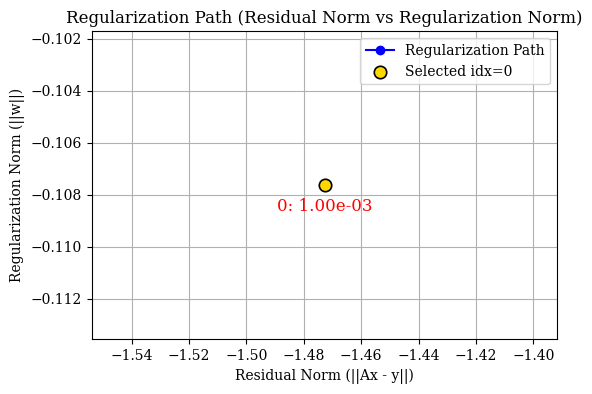

Training error at iteration 0 :
Generalization error at iteration 0 :


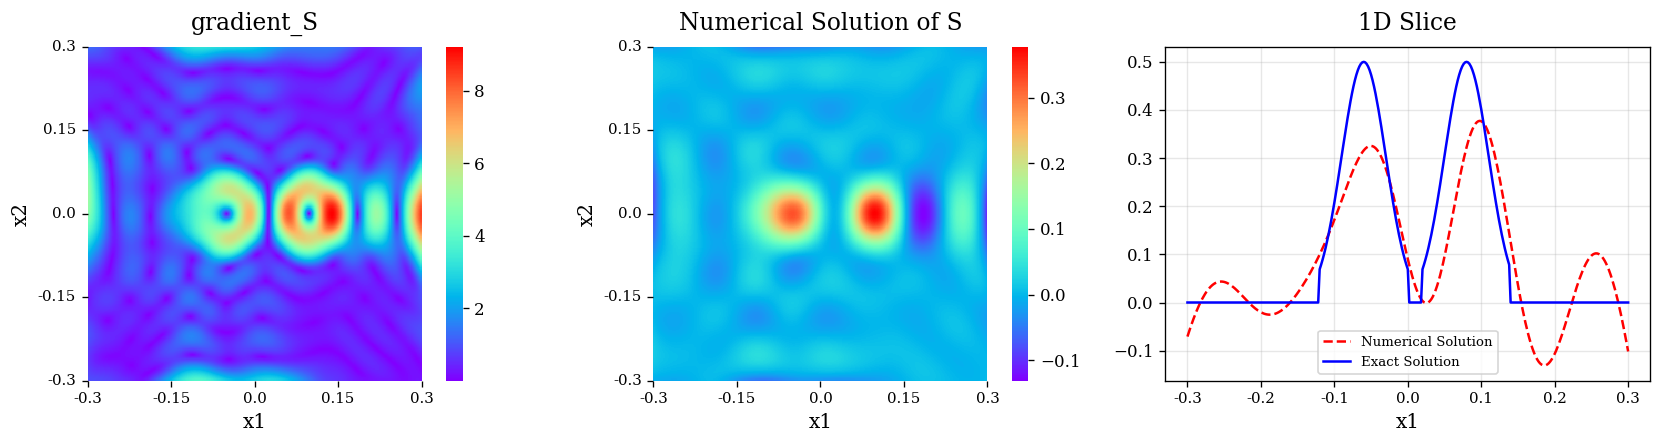

S_l_inf= 3.681562974803646 S_L_2= 0.03210131657455188 S_l_2= 0.5164256576136466
Adaptive mesh refinement at iteration 0 ...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


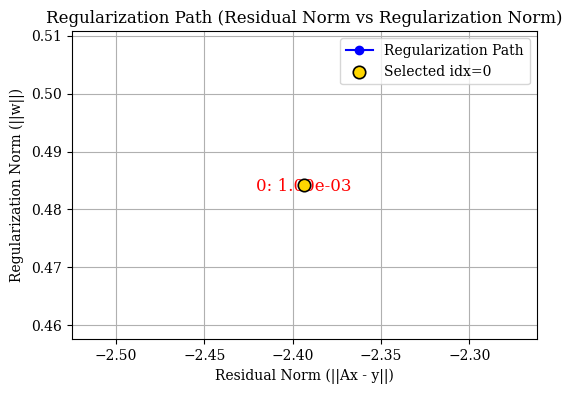

Training error at iteration 1 :
Generalization error at iteration 1 :


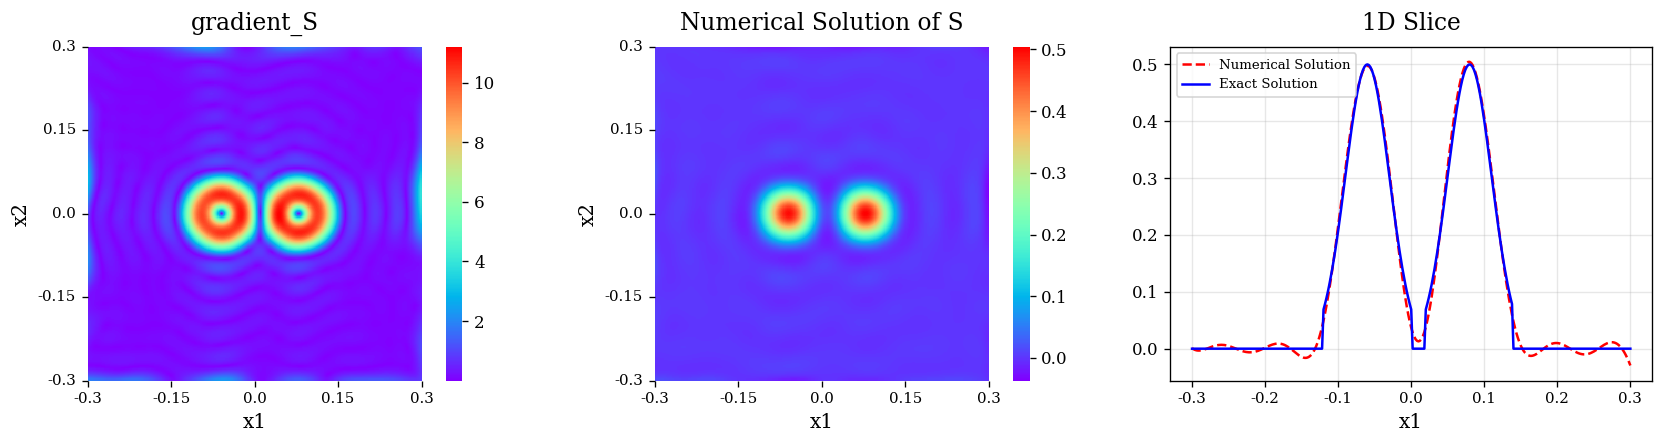

S_l_inf= 0.8862609724154801 S_L_2= 0.006473074666909063 S_l_2= 0.10413472711866222
Adaptive mesh refinement at iteration 1 ...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


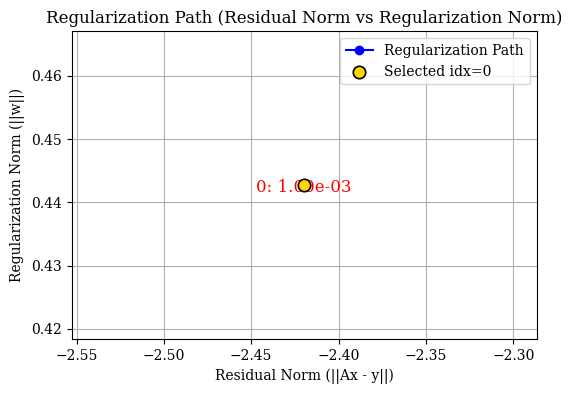

Training error at iteration 2 :
Generalization error at iteration 2 :


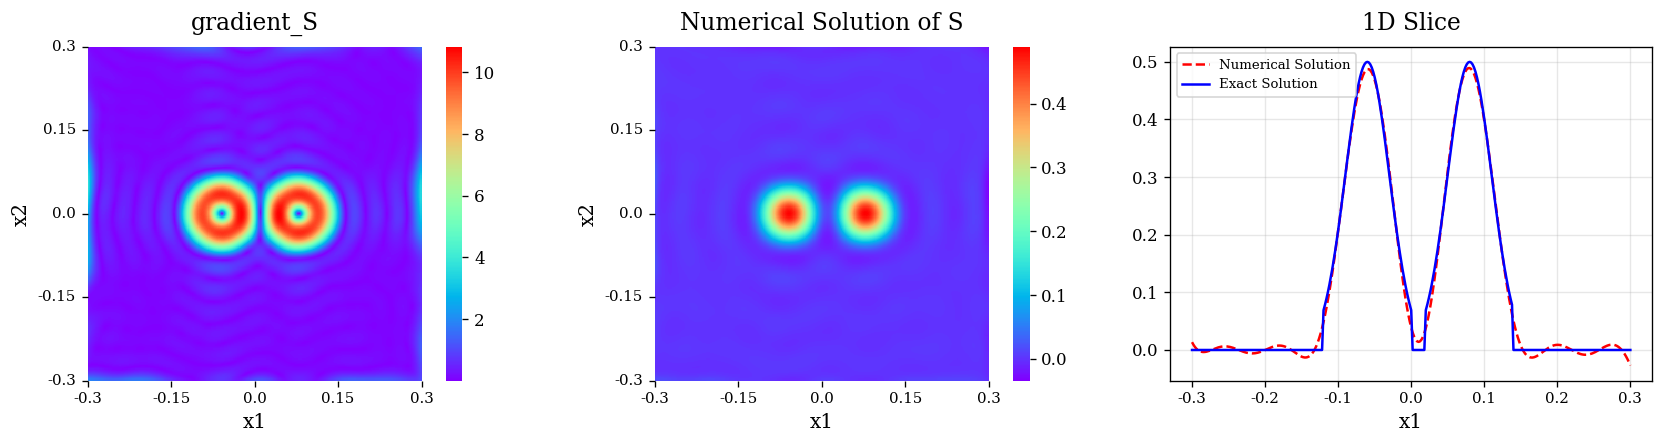

S_l_inf= 0.891515514318889 S_L_2= 0.006253389608630772 S_l_2= 0.10060057298433626
Adaptive mesh refinement at iteration 2 ...
Generating visualizations...
1. Plotting mesh comparison...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


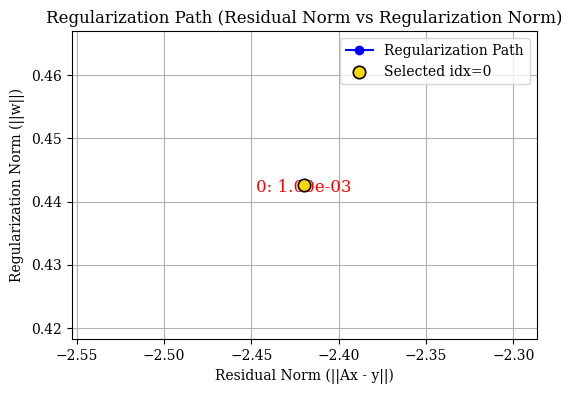

Training error at iteration 3 :
Generalization error at iteration 3 :


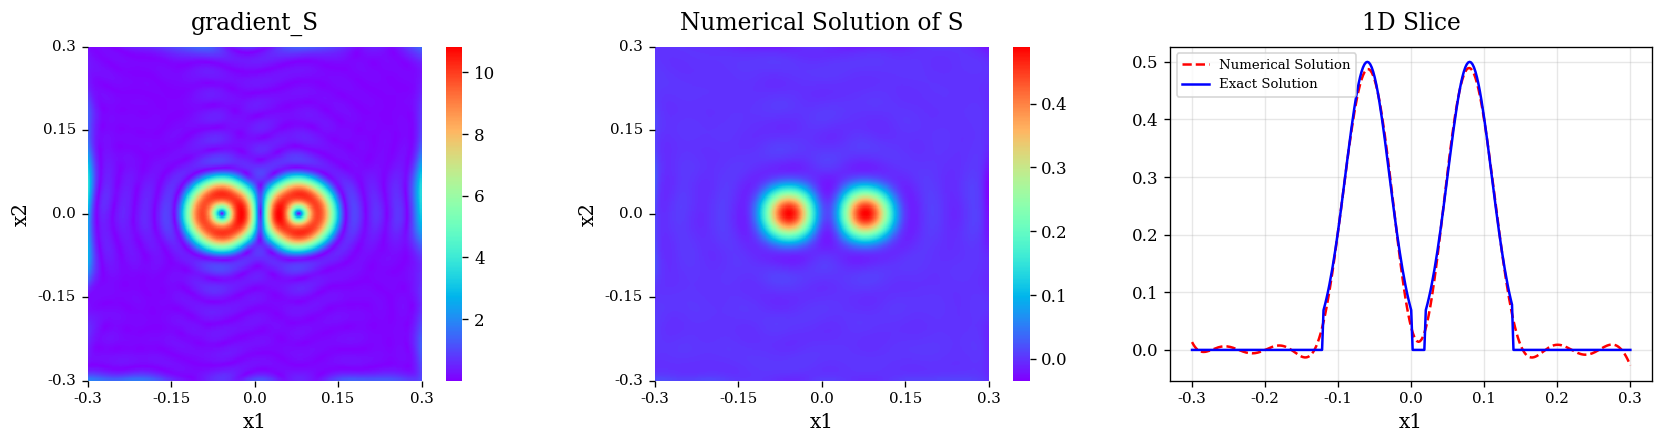

S_l_inf= 0.8914055361549165 S_L_2= 0.006255133380731778 S_l_2= 0.10062862568591001
Stop at iteration 3


In [4]:
from importlib import reload
reload(error_general_2d)
reload(main)
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-3,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=1/100
refine_threshold_grad=1/300
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


In [5]:
np.save("./Noise/noise=10%/g_S.npy",g_S)
np.save("./Noise/noise=10%/S_num_store.npy",S_num_store)


DBSCAN eps = 0.010000 (5.000000 * h, h = 0.002000)
Number of detected clusters: 2
  CV of S_num: 0.744
Cluster 0: AR=1.03
  Res_Rect=0.078904 vs Res_Ellip=0.037945
  center=(-0.0606, 0.0001)
  -> Decision: Ellipsoid (Exp)
  CV of S_num: 0.744
Cluster 1: AR=1.03
  Res_Rect=0.080103 vs Res_Ellip=0.036352
  center=(0.0804, 0.0000)
  -> Decision: Ellipsoid (Exp)


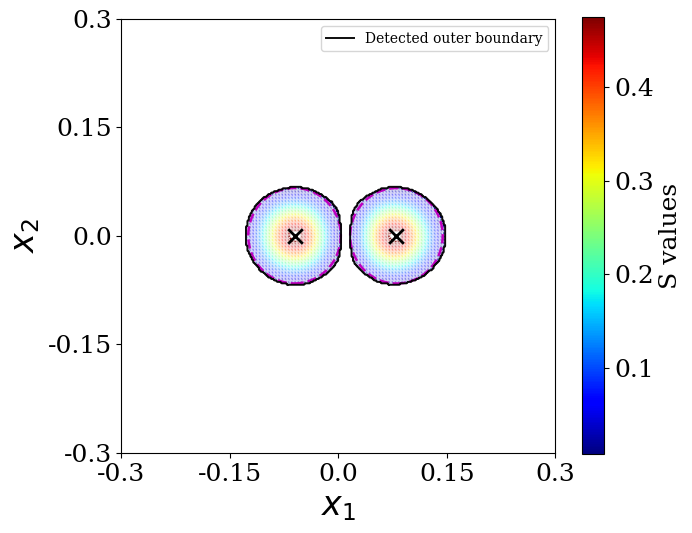

LaTeX table rows:
{\emph{Ex}} & Cluster $k$ & $\boldsymbol{c}_k$ & $r_k$ or $\boldsymbol{L}_k$ & $\mathcal{E}_{\mathrm{rect}}^{(k)}$ & $\mathcal{E}_{\mathrm{ellip}}^{(k)}$ & $\mathrm{AR}_k$ & $\mathrm{CV}_k$ & $\mathcal{T}_k$ & $\sigma_k$ \\
\multirow{2}{*}{Ex 4.4} & 1 & (-6.06e-02, 1.24e-04) & $\boldsymbol{L}$=(6.40e-02, 6.60e-02) & 0.0789 & 0.0379 & 1.03 & 0.744 & \textbf{Ellipsoid} & Exp \\
 & 2 & (8.04e-02, 9.14e-06) & $\boldsymbol{L}$=(6.40e-02, 6.60e-02) & 0.0801 & 0.0364 & 1.03 & 0.744 & \textbf{Ellipsoid} & Exp \\


['{\\emph{Ex}} & Cluster $k$ & $\\boldsymbol{c}_k$ & $r_k$ or $\\boldsymbol{L}_k$ & $\\mathcal{E}_{\\mathrm{rect}}^{(k)}$ & $\\mathcal{E}_{\\mathrm{ellip}}^{(k)}$ & $\\mathrm{AR}_k$ & $\\mathrm{CV}_k$ & $\\mathcal{T}_k$ & $\\sigma_k$ \\\\',
 '\\multirow{2}{*}{Ex 4.4} & 1 & (-6.06e-02, 1.24e-04) & $\\boldsymbol{L}$=(6.40e-02, 6.60e-02) & 0.0789 & 0.0379 & 1.03 & 0.744 & \\textbf{Ellipsoid} & Exp \\\\',
 ' & 2 & (8.04e-02, 9.14e-06) & $\\boldsymbol{L}$=(6.40e-02, 6.60e-02) & 0.0801 & 0.0364 & 1.03 & 0.744 & \\textbf{Ellipsoid} & Exp \\\\']

In [6]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=100
para_grad=3
results = bound_detect.detect_shape(
      g_S,
      X.T,
      Y.T,
      tau_x_min,
      tau_x_max,
      tau_y_min,
      tau_y_max,
      para_abs,
      para_grad,
      eps_cluster,
      mini_samples,
      S_num_store[-1],
      output_directory="./MA_RFM_5%/M=1600+800*2",
      output_filename="plot.png",
      eps_mode="grid_scaled",
      show_detected_boundary=True,
  )

print("LaTeX table rows:")
bound_detect.print_latex_result_rows(results, example_name="Ex 4.4", include_header=True)


In [7]:
results

[{'cluster_id': 0,
  'shape': 'Ellipsoid',
  'params': {'center': array([-0.06056759,  0.00012374]),
   'a': np.float64(0.06399999999999999),
   'b': np.float64(0.06599999999999999),
   'radius': 0.06505249253856858},
  'profile': 'Exp',
  'boundary_points': array([[-0.070292, -0.067728],
         [-0.070624, -0.067396],
         [-0.070956, -0.067396],
         ...,
         [-0.069296, -0.067728],
         [-0.069628, -0.067728],
         [-0.06996 , -0.067728]]),
  'diagnostics': {'Lx': 0.12799999999999997,
   'Ly': 0.13199999999999998,
   'aspect_ratio': 1.03125,
   'res_rect': 0.07890351148183121,
   'res_ellip': 0.03794460689880131,
   'residual_threshold': 0.05,
   'tori_ratio': 0.09989184039665783,
   'r_mean': 0.045005251257238164,
   'min_dist_to_center': 0.006820288429453968,
   'max_dist_to_center': 0.06827673213719426,
   'dist_05': 0.016672437605951617,
   'dist_95': 0.06505249253856858},
  'aspect_ratio': 1.03125,
  'res_rect': 0.07890351148183121,
  'res_ellip': 0.03794

In [8]:
def _gauss_shape_from_result(item):
    params = item["params"]
    center = np.asarray(params["center"], dtype=float)
    if "a" in params and "b" in params:
        a = float(params["a"])
        b = float(params["b"])
    elif "radius" in params:
        a = float(params["radius"])
        b = float(params["radius"])
    elif "R_outer" in params:
        a = float(params["R_outer"])
        b = float(params["R_outer"])
    else:
        boundary = np.asarray(item.get("boundary_points", []), dtype=float)
        if boundary.size == 0:
            raise KeyError("No shape-like parameter or boundary_points in detected result.")
        offsets = boundary - center
        a = 0.5 * (np.max(offsets[:, 0]) - np.min(offsets[:, 0]))
        b = 0.5 * (np.max(offsets[:, 1]) - np.min(offsets[:, 1]))
    a = float(max(a, 1e-12))
    b = float(max(b, 1e-12))
    r_equiv = float(max(a, b))
    return center, a, b, r_equiv

center1, a1, b1, r1 = _gauss_shape_from_result(results[0])
center2, a2, b2, r2 = _gauss_shape_from_result(results[1])


In [9]:
r1

0.06599999999999999

In [10]:
r2

0.06599999999999999

In [11]:
from importlib import reload
reload(net_2d)

# k=1 r=0.2 R_m=0.3 K=1000 M=800*2
M0=2400
M1=2000
M2=2000
R_m=1 #w -0.6~0.6 b: -0.3-0.3
rangee1=[np.abs(center1[0])*0.05,np.abs(center1[1])*2]
rangee2=[np.abs(center2[0])*0.05,np.abs(center2[1])*2]

def _ordered_bounds(v1, v2):
    return (min(float(v1), float(v2)), max(float(v1), float(v2)))

theta_minl, theta_maxl = -1e-12, 1e-12
theta_minr, theta_maxr = -1e-12, 1e-12
b1_minl,b1_maxl = _ordered_bounds(-(center1[0]*(1-0.03)), -(center1[0]*(1+0.03)))
b2_spanl = abs(center1[1])*(1+0.03)
b2_minl,b2_maxl = -b2_spanl, b2_spanl
b1_minr,b1_maxr = _ordered_bounds(-(center2[0]*(1-0.03)), -(center2[0]*(1+0.03)))
b2_spanr = abs(center2[1])*(1+0.03)
b2_minr,b2_maxr = -b2_spanr, b2_spanr
a_minl,a_maxl = _ordered_bounds(a1*(1-0.1), a1*(1+0.03))
b_minl,b_maxl = _ordered_bounds(b1*(1-0.1), b1*(1+0.03))
a_minr,a_maxr = _ordered_bounds(a2*(1-0.1), a2*(1+0.03))
b_minr,b_maxr = _ordered_bounds(b2*(1-0.1), b2*(1+0.03))
v_old_min,v_old_max=-1000,0
peak_min,peak_max=0.3,0.6
K_old_min,K_old_max=1000,20000
# net_2d uses exp(v * metric_sq) * sigmoid(K * (1 - metric_sq))
# with dimensionless ellipse metric_sq = (x_rot/a)^2 + (y_rot/b)^2.
# Convert the legacy dimensional v and K by absorbing the ellipse area scale a*b.
v_minl,v_maxl = v_old_min * (a1 * b1), v_old_max * (a1 * b1)
v_minr,v_maxr = v_old_min * (a2 * b2), v_old_max * (a2 * b2)
K_minl,K_maxl = K_old_min * (a1 * b1), K_old_max * (a1 * b1)
K_minr,K_maxr = K_old_min * (a2 * b2), K_old_max * (a2 * b2)
R_m0 = 5
# Recreate models0 after reload(net_2d); otherwise torch.save(models0, ...)
# hits a PicklingError because the class identity changed after reload.
models0 = net_2d.pre_define(Nx,Ny,M0,R_m0,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)
#models0 = net_2d.pre_define(Nx,Ny,M0,1,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min1,b1_max1,b2_min1,b2_max1,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
models1 = net_2d.pre_define(Nx,Ny,M1,1,"Gauss",tau_x_min,tau_x_max,tau_y_min,tau_y_max,theta_minl,theta_maxl,b1_minl,b1_maxl,b2_minl,b2_maxl,a_minl,a_maxl,b_minl,b_maxl,peak_min,peak_max,v_minl,v_maxl,K_minl,K_maxl,"elliptic_gauss",device)
models2 = net_2d.pre_define(Nx,Ny,M2,1,"Gauss",tau_x_min,tau_x_max,tau_y_min,tau_y_max,theta_minr,theta_maxr,b1_minr,b1_maxr,b2_minr,b2_maxr,a_minr,a_maxr,b_minr,b_maxr,peak_min,peak_max,v_minr,v_maxr,K_minr,K_maxr,"elliptic_gauss",device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1=matrix_assemble.mat_assemble2(cells_store[-1],models0,models1,models2,"mix",kk,0,points_b,device,cupy_device)


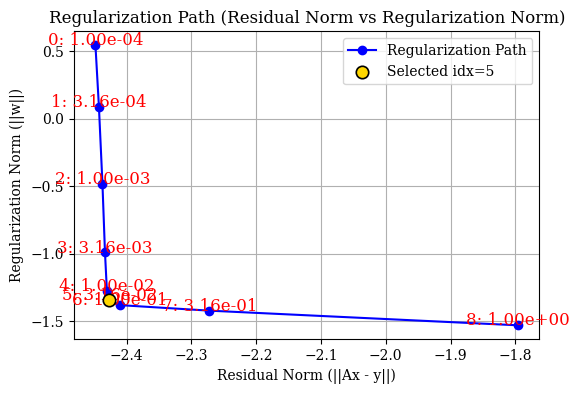

In [13]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(M0,M1,M2,af,sum_mat,F,lamb_regu,cupy_device) # Solve first

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=9.145297e-02
  idx=5, lambda=3.162278e-02, curvature=7.014230e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=3.337147e+00
candidate idx: [4 5 6]
candidate lambda: [0.01       0.03162278 0.1       ]


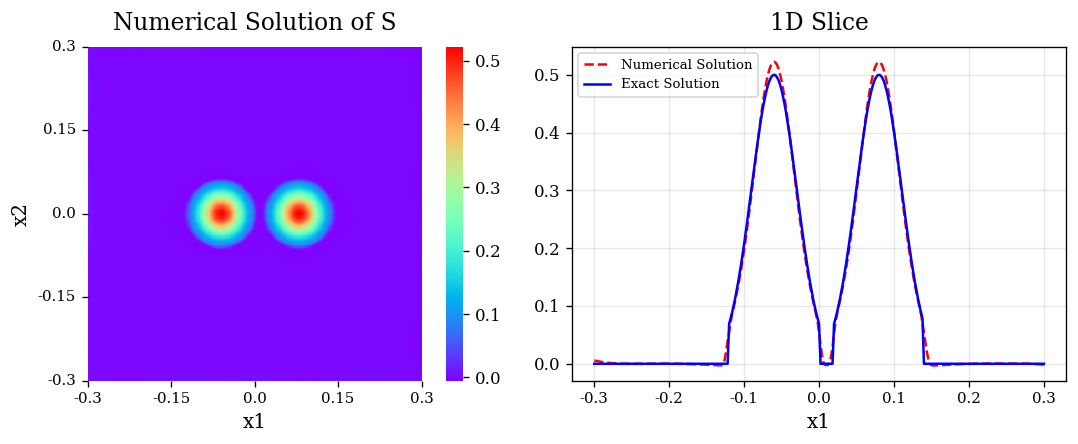

S_l_inf= 0.950360628999822 S_L_2= 0.0037514951716535625 S_l_2= 0.060351679238958296
candidate idx=4, lamb=0.0001, S_l_inf=0.950360628999822, S_l_2=0.060351679238958296


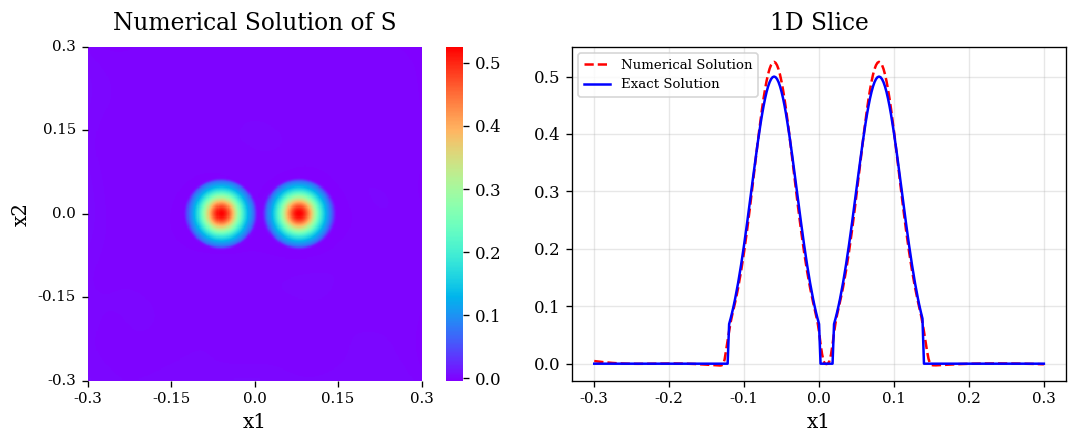

S_l_inf= 0.9696292595063686 S_L_2= 0.0041080669412395885 S_l_2= 0.06608798012142438
candidate idx=5, lamb=0.0009999999999999998, S_l_inf=0.9696292595063686, S_l_2=0.06608798012142438


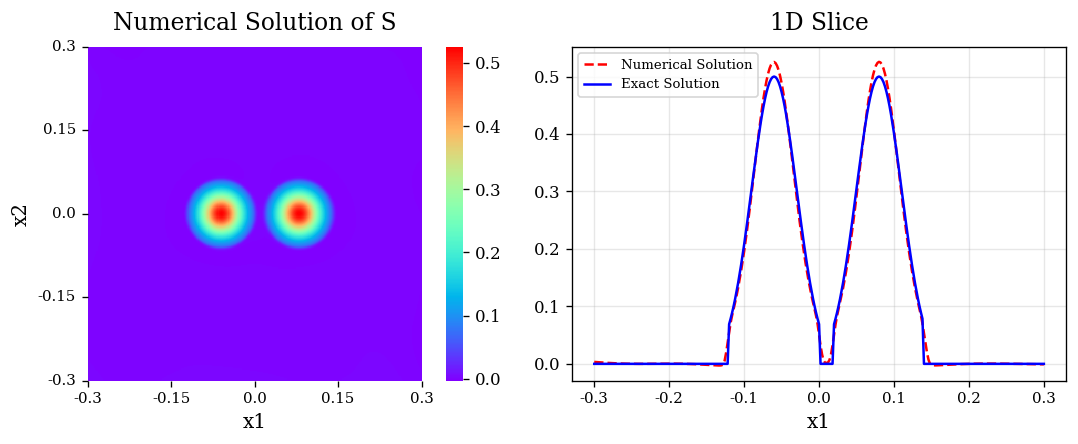

S_l_inf= 0.9961221119249722 S_L_2= 0.004260198809781471 S_l_2= 0.06853538130739369
candidate idx=6, lamb=0.010000000000000002, S_l_inf=0.9961221119249722, S_l_2=0.06853538130739369
picked idx: 4
lamb: 0.0001


In [14]:
reload(inverse_solver)
window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
    lamb_regu, res, reg_norm, radius=1, w_store=w_store
)
print('candidate idx:', window_idx)
print('candidate lambda:', window_lambda)
window_results = []
for local_i, cand_idx in enumerate(window_idx):
    cand_lamb = window_lambda[local_i]**2
    cand_w = window_w[:, local_i]
    result_tuple = error_general_2d.test(models0,models1,models2,150,150,cand_w,"mix",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,ana_S,0,device)
    window_results.append({
        'idx': int(cand_idx),
        'lambda': cand_lamb,
        'w': cand_w,
        'result': result_tuple,
    })
    print(
        f"candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
        f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
    )
pick = 0
picked = window_results[pick]
idx = picked['idx']
lamb = picked['lambda']
picked_w = picked['w']
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=picked['result']
print('picked idx:', idx)
print('lamb:', lamb)


In [15]:
# Save the models1 model
torch.save(models0,f"./Noise/noise=10%/models0_33_2400_{point_number[-1]}_{lamb}.pth")
torch.save(models1,f"./Noise/noise=10%/models1_33_2000_left_elliptic_gauss.pth")
torch.save(models2,f"./Noise/noise=10%/models2_33_2000_right_elliptic_gauss.pth")

In [16]:
np.save(f"./Noise/noise=10%/S_num_{lamb}",S_test_num)
np.save("./Noise/noise=10%/all_mat",sum_mat)
np.save("./Noise/noise=10%/w_store",w_store)
np.save("./Noise/noise=10%/F_mea_b",F_mea_b0)
np.save("./Noise/noise=10%/F_mea_db_x1",F_mea_db_x10)
np.save("./Noise/noise=10%/F_mea_db_x2",F_mea_db_x20)
np.save("./Noise/noise=10%/F",F)

In [17]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('a1:', a1)
print('b1:', b1)
print('r1:',r1)
print('a2:', a2)
print('b2:', b2)
print('r2:',r2)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)


n_integral: 3006
center1[0]: [-0.06056759  0.00012374]
center2[1]: [8.03820122e-02 9.13761468e-06]
a1: 0.06399999999999999
b1: 0.06599999999999999
r1: 0.06599999999999999
a2: 0.064
b2: 0.06599999999999999
r2: 0.06599999999999999
S_l2[-1]: 0.10062862568591001
lamb_regu: 0.0001
S_l21: 0.060351679238958296
